# French Artistic Heritage in the Metropolitan Museum Collection

This notebook investigates the representation of French artistic heritage within the Metropolitan Museum of Art Open Access collection using museum metadata and digital humanities methods.

# Research Question

What aspects of French artistic heritage are most prominently represented in the Metropolitan Museum of Art collection?

## Workflow

The workflow of this project consists of the following stages:

1. Data collection from the Metropolitan Museum Open Access dataset.
2. Loading and inspection of the dataset using pandas.
3. Selection of relevant metadata variables.
4. Data cleaning and missing value analysis.
5. Identification and filtering of French heritage objects.
6. Exploratory analysis of selected variables.
7. Visualisation of patterns and distributions.
8. Interpretation of results and discussion of findings.
9. Documentation of the workflow in a reproducible Jupyter Notebook.

# Analytical Approach

This project uses the Metropolitan Museum Open Access dataset to explore French artistic heritage through museum metadata. The analysis focuses on Culture, Department, Object Name, Classification, and AccessionYear.

# Data Access and Initial Inspection

In [26]:
import pandas as pd 


In [27]:
df = pd.read_csv(
    "https://media.githubusercontent.com/media/metmuseum/openaccess/master/MetObjects.csv",
    low_memory=False
)

df.shape

(484956, 54)

### Note on Data Loading

This notebook preserves the original research workflow. It begins with the complete Metropolitan Museum Open Access dataset, explores its cultures, artist nationalities, departments, and missing values, and then identifies French artistic heritage as the research focus.

Records are subsequently filtered where either the `Culture` field or the `Artist Nationality` field equals `"French"`. This produced 36,919 records in the dataset snapshot used for this project.

Because the Metropolitan Museum periodically updates its source dataset, newly generated results may differ slightly. The archived filtered dataset used for the reported results is available in `Data/french_heritage_objects.csv` and on Zenodo: https://doi.org/10.5281/zenodo.21347584.

## Dataset Overview

The first rows of the dataset are displayed to inspect the structure of the data and the metadata available for each museum object.

In [28]:
df.head ()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [29]:
df.columns

Index(['Object Number', 'Is Highlight', 'Is Timeline Work', 'Is Public Domain',
       'Object ID', 'Gallery Number', 'Department', 'AccessionYear',
       'Object Name', 'Title', 'Culture', 'Period', 'Dynasty', 'Reign',
       'Portfolio', 'Constituent ID', 'Artist Role', 'Artist Prefix',
       'Artist Display Name', 'Artist Display Bio', 'Artist Suffix',
       'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date',
       'Artist End Date', 'Artist Gender', 'Artist ULAN URL',
       'Artist Wikidata URL', 'Object Date', 'Object Begin Date',
       'Object End Date', 'Medium', 'Dimensions', 'Credit Line',
       'Geography Type', 'City', 'State', 'County', 'Country', 'Region',
       'Subregion', 'Locale', 'Locus', 'Excavation', 'River', 'Classification',
       'Rights and Reproduction', 'Link Resource', 'Object Wikidata URL',
       'Metadata Date', 'Repository', 'Tags', 'Tags AAT URL',
       'Tags Wikidata URL'],
      dtype='object')

## Selected Variables

The variables Culture, Artist Nationality, and Department were selected for further exploration because they are relevant for analyzing cultural representation and institutional categorization within the collection.

In [30]:
df[["Culture", "Artist Nationality", "Department"]].head()

,Culture,Artist Nationality,Department
0,NaN,American,The American Wing
1,NaN,American,The American Wing
2,NaN,NaN,The American Wing
3,NaN,NaN,The American Wing
4,NaN,NaN,The American Wing


## Culture Distribution

The most frequent cultural categories in the dataset are examined to understand the cultural composition of the collection.

In [31]:
df["Culture"].value_counts().head(20)

Culture
American                28579
French                  18435
Greek, Attic            17309
Japan                   16939
China                   13504
Italian                  6526
Japanese                 5990
British                  5476
Roman                    4872
German                   4576
Cypriot                  2904
European                 2669
American or European     2052
Coptic                   1674
French, Paris            1622
Spanish                  1563
British, London          1408
Greek                    1263
Etruscan                 1234
Iran                     1070
Name: count, dtype: int64

## Department Distribution

The distribution of museum departments is examined to understand how objects are institutionally organized within the Metropolitan Museum collection.

In [32]:
df["Department"].value_counts()

Department
Drawings and Prints                          172630
European Sculpture and Decorative Arts        43051
Photographs                                   37459
Asian Art                                     37000
Greek and Roman Art                           33726
Costume Institute                             31652
Egyptian Art                                  27969
The American Wing                             18532
Islamic Art                                   15573
Modern and Contemporary Art                   14696
Arms and Armor                                13623
Arts of Africa, Oceania, and the Americas     12367
Medieval Art                                   7142
Ancient Near Eastern Art                       6223
Musical Instruments                            5227
European Paintings                             2626
Robert Lehman Collection                       2586
The Cloisters                                  2340
The Libraries                                   534
N

## Missing Values Analysis

In [33]:
df[["Culture", "Artist Nationality", "Department"]].isnull().sum()

Culture               276766
Artist Nationality    202443
Department                 0
dtype: int64

## Interpretation of Missing Values

A substantial number of missing values are present in the variables Culture and Artist Nationality. In contrast, the Department variable contains no missing values. This suggests that departmental information is consistently recorded, whereas cultural and nationality information is unavailable for a considerable portion of the collection.

In [34]:
df[["Culture", "Artist Nationality", "Department"]].describe(include="all")

,Culture,Artist Nationality,Department
count,208190,282513,484956
unique,7313,6945,19
top,American,American,Drawings and Prints
freq,28579,69831,172630


## Relevance of Selected Variables

The variables Culture, Artist Nationality, and Department were selected because they are directly related to the research question. Culture identifies the cultural origin of museum objects, Artist Nationality provides information about the background of artists, and Department shows how objects are institutionally categorized within the museum. Together, these variables support the exploration of French artistic heritage in the Metropolitan Museum collection.

## Filtering French Heritage Objects

To focus on the research question, the dataset is filtered to objects associated with French artistic heritage. The Culture and Artist Nationality variables are used to identify records related to France.

In [35]:
french_df = df[
    (df["Culture"] == "French") |
    (df["Artist Nationality"] == "French")
]

french_df.shape

(36919, 54)

## Department Distribution within French Heritage Objects

The distribution of French heritage objects across museum departments is examined to identify which institutional areas contain the strongest representation of French artistic heritage.

In [36]:
french_df["Department"].value_counts().head(20)

Department
Drawings and Prints                       12225
European Sculpture and Decorative Arts     8730
Costume Institute                          7868
Photographs                                3010
European Paintings                          904
The Cloisters                               892
Modern and Contemporary Art                 837
Medieval Art                                709
Arms and Armor                              614
Robert Lehman Collection                    396
The American Wing                           354
Musical Instruments                         348
The Libraries                                27
Islamic Art                                   3
Greek and Roman Art                           1
Asian Art                                     1
Name: count, dtype: int64

## Interpretation of Department Distribution

French artistic heritage is most strongly represented in the departments Drawings and Prints, European Sculpture and Decorative Arts, Costume Institute, and Photographs. This suggests that French heritage within the Metropolitan Museum collection is particularly associated with graphic arts, decorative arts, fashion, and photography. The strong presence of European-focused departments further highlights the importance of French artistic production within the museum's representation of European cultural heritage.

## Visualization of Department Distribution

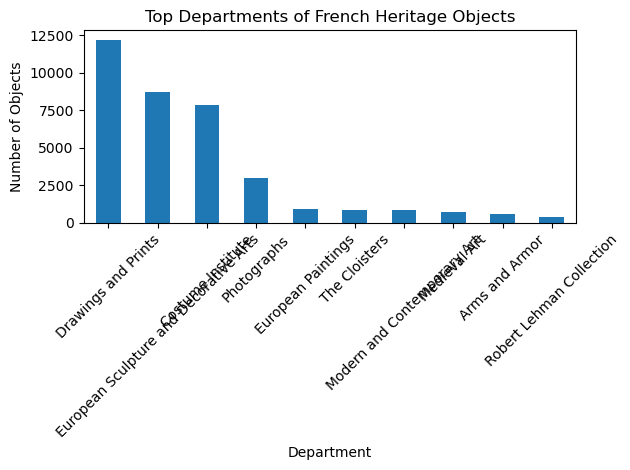

In [37]:
import matplotlib.pyplot as plt

french_df["Department"].value_counts().head(10).plot(kind="bar")

plt.title("Top Departments of French Heritage Objects")
plt.xlabel("Department")
plt.ylabel("Number of Objects")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Interpretation of Department Visualization

The visualization confirms that Drawings and Prints, European Sculpture and Decorative Arts, and the Costume Institute contain the largest numbers of French heritage objects. The clear difference between these departments and the remaining categories indicates that French artistic heritage is primarily represented through graphic arts, decorative arts, fashion, and photography. The distribution also shows that French heritage is present across a variety of museum departments, reflecting the diversity of French artistic production.

## Classification Distribution within French Heritage Objects

The distribution of object classifications is examined to identify which types of French heritage objects are most prominently represented in the collection.

In [38]:
french_df["Classification"].value_counts().head(20)

Classification
Prints                                  5334
Drawings                                3706
Photographs                             2832
Textiles-Woven                          1692
Paintings                               1036
Prints|Ornament & Architecture           913
Textiles-Trimmings                       885
Cut Paper|Ephemera                       835
Metalwork-Gilt Bronze                    829
Medals and Plaquettes                    681
Drawings|Ornament & Architecture         637
Textiles-Laces                           633
Textiles-Embroidered                     539
Books                                    485
Woodwork-Furniture                       457
Sculpture-Architectural                  387
Woodwork                                 376
Ceramics-Porcelain                       372
Sculpture                                311
Books|Prints|Ornament & Architecture     296
Name: count, dtype: int64

## French Heritage Identification

To understand how French artistic heritage is represented in the collection, the number of objects identified through Culture and Artist Nationality is examined.

In [39]:
french_df[["Culture","Artist Nationality"]].describe(include="all")

,Culture,Artist Nationality
count,19671,26329
unique,139,193
top,French,French
freq,18435,21639


## Interpretation of French Heritage Identification

The French heritage subset contains objects identified through both the Culture and Artist Nationality variables. The Artist Nationality field contains more French-related records than the Culture field, suggesting that French heritage in the Metropolitan Museum collection is more frequently documented through the nationality of artists than through explicit cultural classification. This highlights the importance of combining both variables when identifying French artistic heritage objects and provides a broader representation of French contributions within the collection.

## Visualization of French Heritage Classifications

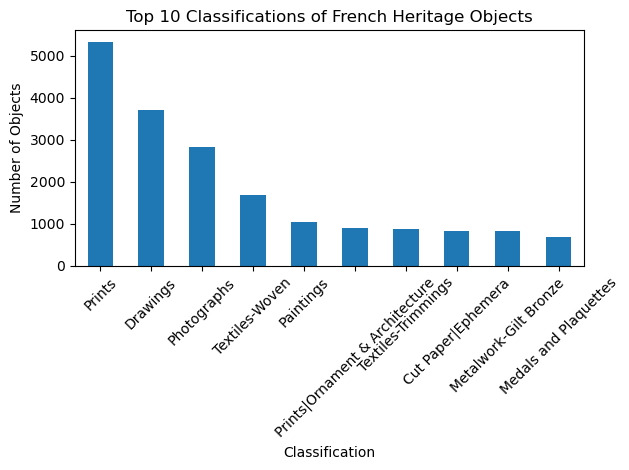

In [40]:
import matplotlib.pyplot as plt

french_df["Classification"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Classifications of French Heritage Objects")
plt.xlabel("Classification")
plt.ylabel("Number of Objects")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Interpretation of Classification Visualization

The visualization confirms that Prints, Drawings, and Photographs are the most dominant classifications among French heritage objects in the Metropolitan Museum collection. The large difference between these categories and the remaining classifications indicates that French artistic heritage is particularly represented through visual and graphic arts. Textile-related categories and paintings are also present but in smaller numbers, demonstrating the diversity of French artistic production preserved in the collection.

## Comparison of Culture and Artist Nationality

To further understand how French artistic heritage is represented in the collection, the variables Culture and Artist Nationality are compared. This comparison helps determine whether French heritage is primarily identified through cultural classification or through the nationality of artists associated with museum objects.

In [41]:
comparison = {
    "Culture (French)": (french_df["Culture"] == "French").sum(),
    "Artist Nationality (French)": (french_df["Artist Nationality"] == "French").sum()
}

pd.Series(comparison)

Culture (French)               18435
Artist Nationality (French)    21639
dtype: int64

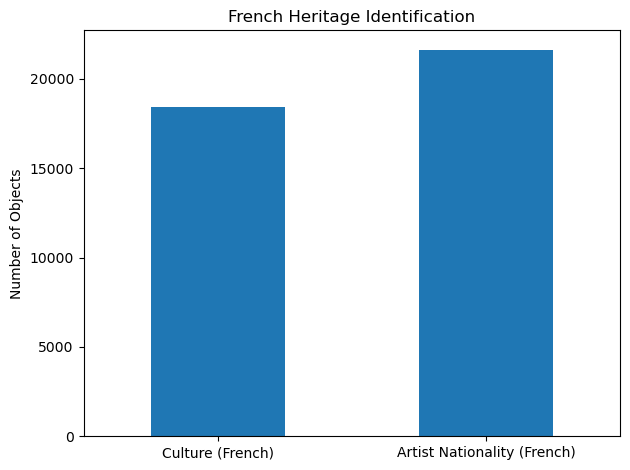

In [42]:
pd.Series(comparison).plot(kind="bar")

plt.title("French Heritage Identification")
plt.ylabel("Number of Objects")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Interpretation of Culture and Artist Nationality Comparison

The comparison shows that French heritage objects are identified through both cultural classification and artist nationality. The collection contains 18,435 objects classified as French culture and 21,639 objects associated with French artist nationality. The higher number of objects linked to French artists suggests that the contribution of French artists plays an especially important role in the representation of French heritage within the Metropolitan Museum collection. Considering both variables provides a broader understanding of how French artistic heritage is documented and preserved.

## Potential Metadata Enhancement

The current analysis relies on metadata provided by the Metropolitan Museum. Future work could enhance the dataset by linking artists and objects to external open heritage resources such as Wikidata. Such enrichment could provide additional information about artists, historical periods, artistic movements, and geographical contexts, enabling a more detailed analysis of French artistic heritage.

## Limitations

This analysis depends on the completeness and accuracy of museum metadata. Some records contain missing values, and metadata fields such as Culture and Artist Nationality may not fully capture the complexity of artistic heritage. Furthermore, the analysis is limited to information available in the dataset and does not include external historical or biographical sources.

## Accession Year Analysis

To investigate when French heritage objects entered the Metropolitan Museum collection, the distribution of accession years is examined. This analysis helps identify periods during which French heritage was most actively acquired.

In [43]:
french_df["AccessionYear"].value_counts().sort_index().tail(20)

AccessionYear
2004     188
2005    1443
2006     256
2007     154
2008     100
2009    2079
2010      97
2011      95
2012     351
2013     185
2014     103
2015      99
2016     126
2017     124
2018     220
2019     171
2020     108
2021     103
2022      87
2023      41
Name: count, dtype: int64

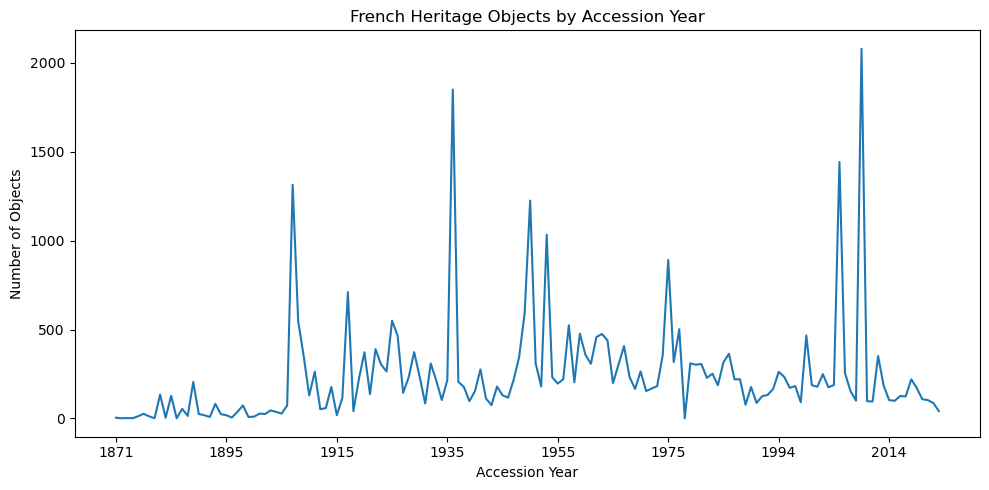

In [44]:
import matplotlib.pyplot as plt

french_df["AccessionYear"].value_counts().sort_index().plot(figsize=(10,5))

plt.title("French Heritage Objects by Accession Year")
plt.xlabel("Accession Year")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

## Interpretation of Accession Year Analysis

The accession year analysis reveals that French heritage objects entered the Metropolitan Museum collection in distinct waves rather than at a constant rate over time. Several notable peaks can be observed, particularly around the early twentieth century, the late 1930s, the 1950s, and the period between 2010 and 2015.

The strongest increase occurs during the most recent acquisition period, suggesting that a substantial number of French heritage objects were incorporated into the collection during these years. Earlier peaks indicate previous periods of intensified collecting activity, reflecting changing museum priorities and acquisition strategies over time.

These findings demonstrate that the representation of French artistic heritage within the Metropolitan Museum collection is not only shaped by cultural and artistic classifications but also by historical patterns of acquisition. The temporal analysis therefore provides an additional perspective on how French heritage became established within the museum's holdings.

## Reproducibility

This notebook documents all stages of the research process from data access to final visualisations. All code, analyses, and interpretations are presented in a transparent manner so that another researcher can reproduce the workflow by running the notebook from top to bottom using the same dataset and software environment.

## FAIR Principles

Findable: The dataset is publicly available through the Metropolitan Museum Open Access repository.

Accessible: The dataset can be freely downloaded and accessed.

Interoperable: The metadata is provided in CSV format and can be analysed using different software tools.

Reusable: The dataset is openly licensed and the workflow is fully documented in this notebook.

## Open Scholarship

This project uses openly available cultural heritage data from the Metropolitan Museum of Art Open Access collection. All analytical steps are documented in a Jupyter Notebook and the project is shared through GitHub. The workflow promotes transparency, reproducibility, accessibility, and reuse of research materials in accordance with open scholarship principles.

## Conclusion

This project investigated the representation of French artistic heritage within the Metropolitan Museum collection using museum metadata from the Open Access dataset. The analysis focused on the variables Culture, Artist Nationality, Department, and Classification.

The results show that French heritage is strongly represented in departments such as Drawings and Prints, European Sculpture and Decorative Arts, the Costume Institute, and Photographs. The classification analysis revealed that prints, drawings, photographs, and textile-related objects are the most common forms of French heritage represented in the collection.

The comparison between Culture and Artist Nationality further demonstrated that French heritage is documented both through cultural classification and through the nationality of artists, with artist nationality accounting for a larger number of records.

Overall, the findings indicate that French artistic heritage occupies a significant and diverse position within the Metropolitan Museum collection and is represented across multiple departments, object types, and artistic traditions.